In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.ToTensor()

mnist = MNIST(root="./data", train=True, download=True, transform=transform)

images = []
labels = []

for img, label in mnist:
    if label in [1,2]:
        images.append(img)
        labels.append(label)

images = torch.stack(images)
labels = torch.tensor(labels)

angles = list(range(0,360,30))

rotated_images = []
rotation_labels = []

for img in images:
    for angle in angles:
        rotated = TF.rotate(img, angle)
        rotated_images.append(rotated)
        rotation_labels.append(angle)

rotated_images = torch.stack(rotated_images)
rotation_labels = torch.tensor(rotation_labels)

print(rotated_images.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.81MB/s]


torch.Size([152400, 1, 28, 28])


In [4]:
latent_dim = 32

class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,4,stride=2,padding=1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64*7*7,latent_dim)
        self.fc_logvar = nn.Linear(64*7*7,latent_dim)

    def forward(self,x):

        x = self.conv(x)
        x = x.view(x.size(0),-1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu,logvar


class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(latent_dim,64*7*7)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def forward(self,z):

        x = self.fc(z)
        x = x.view(-1,64,7,7)

        return self.deconv(x)


class VAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self,mu,logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std

In [5]:
dataset = TensorDataset(rotated_images)
loader = DataLoader(dataset,batch_size=256,shuffle=True)

vae = VAE().to(device)

optimizer = optim.Adam(vae.parameters(),lr=1e-3)

def vae_loss(recon,x,mu,logvar):

    recon_loss = F.binary_cross_entropy(recon,x,reduction="sum")

    kl = -0.5*torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl


epochs = 20

for epoch in range(epochs):

    total_loss = 0

    for (batch,) in loader:

        batch = batch.to(device)

        mu,logvar = vae.encoder(batch)

        z = vae.reparameterize(mu,logvar)

        recon = vae.decoder(z)

        loss = vae_loss(recon,batch,mu,logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch",epoch+1,"Loss",total_loss/len(loader.dataset))

Epoch 1 Loss 130.3417752740014
Epoch 2 Loss 99.74465688309958
Epoch 3 Loss 96.71750320394521
Epoch 4 Loss 95.27940799743172
Epoch 5 Loss 94.30238258181595
Epoch 6 Loss 93.61490266734846
Epoch 7 Loss 93.0200285599676
Epoch 8 Loss 92.55980892952346
Epoch 9 Loss 92.1485317408444
Epoch 10 Loss 91.84563647653174
Epoch 11 Loss 91.50677603013246
Epoch 12 Loss 91.29185708994628
Epoch 13 Loss 91.05851827786664
Epoch 14 Loss 90.8274882639487
Epoch 15 Loss 90.6450073210148
Epoch 16 Loss 90.47802142285926
Epoch 17 Loss 90.32254166410351
Epoch 18 Loss 90.18165722143618
Epoch 19 Loss 90.05492268880208
Epoch 20 Loss 89.92326950433686


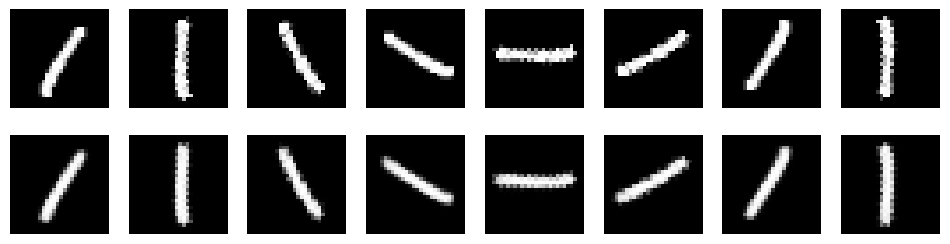

In [6]:
vae.eval()

sample = rotated_images[:8].to(device)

with torch.no_grad():

    mu,_ = vae.encoder(sample)

    recon = vae.decoder(mu)

sample = sample.cpu()
recon = recon.cpu()

fig,ax = plt.subplots(2,8,figsize=(12,3))

for i in range(8):

    ax[0,i].imshow(sample[i].squeeze(),cmap="gray")
    ax[0,i].axis("off")

    ax[1,i].imshow(recon[i].squeeze(),cmap="gray")
    ax[1,i].axis("off")

plt.show()

In [7]:
latent_vectors = []

with torch.no_grad():

    for (batch,) in loader:

        batch = batch.to(device)

        mu,_ = vae.encoder(batch)

        latent_vectors.append(mu.cpu())

latent_vectors = torch.cat(latent_vectors)

print(latent_vectors.shape)

torch.Size([152400, 32])


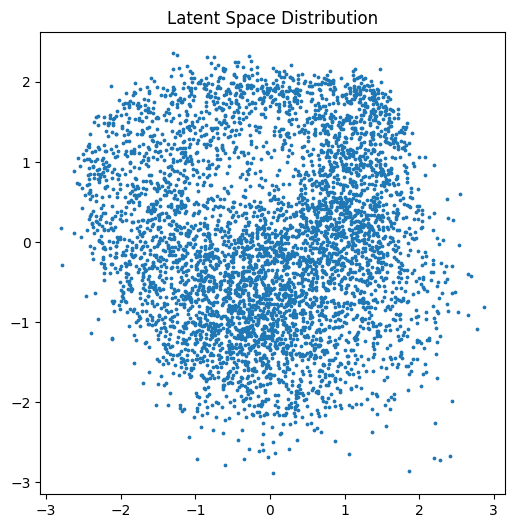

In [8]:
sample_z = latent_vectors[:5000].numpy()

pca = PCA(n_components=2)

z_2d = pca.fit_transform(sample_z)

plt.figure(figsize=(6,6))

plt.scatter(z_2d[:,0],z_2d[:,1],s=3)

plt.title("Latent Space Distribution")

plt.show()

In [9]:
class LatentClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,2)
        )

    def forward(self,z):

        return self.net(z)


classifier = LatentClassifier().to(device)

optimizer = optim.Adam(classifier.parameters(),lr=1e-3)

criterion = nn.CrossEntropyLoss()

labels_binary = (labels.repeat_interleave(12)-1)

dataset = TensorDataset(latent_vectors,labels_binary)

loader = DataLoader(dataset,batch_size=256,shuffle=True)

for epoch in range(10):

    total_loss = 0

    for z_batch,y_batch in loader:

        z_batch = z_batch.to(device)
        y_batch = y_batch.to(device)

        preds = classifier(z_batch)

        loss = criterion(preds,y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch",epoch+1,total_loss/len(loader))

Epoch 1 0.6917881751620529
Epoch 2 0.6911159224758212
Epoch 3 0.6906863743026784
Epoch 4 0.6902305179794362
Epoch 5 0.6894589996577909
Epoch 6 0.6886325588562344
Epoch 7 0.6871578981412337
Epoch 8 0.6854849049708988
Epoch 9 0.6835984528664775
Epoch 10 0.6814830461204452


In [10]:
class SymmetryGenerator(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,latent_dim)
        )

    def forward(self,z):

        g = self.net(z)

        g = F.normalize(g,dim=1)

        return g


generator = SymmetryGenerator().to(device)

optimizer = optim.Adam(generator.parameters(),lr=3e-4)

epsilon = 0.02

In [11]:
for epoch in range(30):

    total_loss = 0

    for z_batch,_ in loader:

        z_batch = z_batch.to(device)

        g = generator(z_batch)

        z_new = z_batch + epsilon*g

        logits_old = classifier(z_batch)
        logits_new = classifier(z_new)

        inv_loss = F.mse_loss(logits_old,logits_new)

        norm_loss = ((torch.norm(g,dim=1)-1)**2).mean()

        loss = inv_loss + 0.1*norm_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch",epoch+1,total_loss/len(loader))

Epoch 1 3.115227388563452e-07
Epoch 2 1.779489408920959e-07
Epoch 3 1.5367088281363488e-07
Epoch 4 1.4036621598676976e-07
Epoch 5 1.3163374555022943e-07
Epoch 6 1.252915401376309e-07
Epoch 7 1.2048591211086945e-07
Epoch 8 1.1655018032267005e-07
Epoch 9 1.1329550251874532e-07
Epoch 10 1.1030430371332025e-07
Epoch 11 1.0791097945716714e-07
Epoch 12 1.0564263535252165e-07
Epoch 13 1.0382488384317755e-07
Epoch 14 1.0201596538147502e-07
Epoch 15 1.0047159120781407e-07
Epoch 16 9.894761043327761e-08
Epoch 17 9.742912769775255e-08
Epoch 18 9.618430885168909e-08
Epoch 19 9.504131457677182e-08
Epoch 20 9.399734352846037e-08
Epoch 21 9.292971986560633e-08
Epoch 22 9.197711590419637e-08
Epoch 23 9.093180147112279e-08
Epoch 24 9.007529887967684e-08
Epoch 25 8.925717671905543e-08
Epoch 26 8.856901643712751e-08
Epoch 27 8.772161471786271e-08
Epoch 28 8.699517628272988e-08
Epoch 29 8.608795114506109e-08
Epoch 30 8.542851612691152e-08


In [12]:
with torch.no_grad():

    z = latent_vectors[:1000].to(device)

    g = generator(z)

    z_new = z + epsilon*g

    logits_old = classifier(z)
    logits_new = classifier(z_new)

    diff = torch.mean((logits_old-logits_new)**2)

print("Logit invariance error:",diff.item())

Logit invariance error: 7.842359650567232e-08


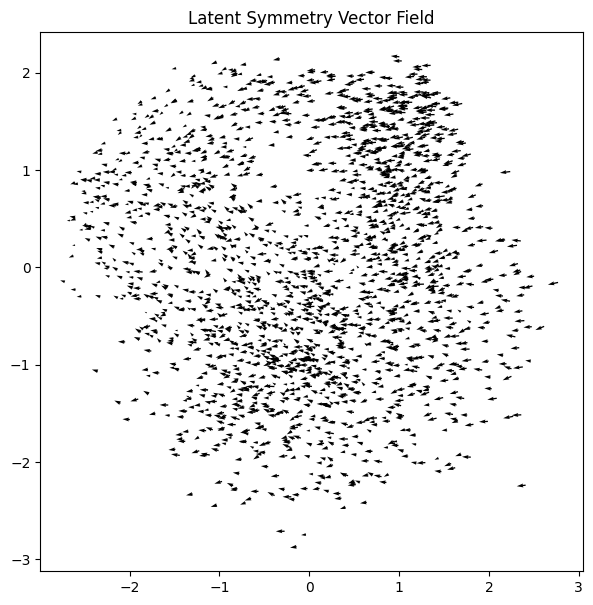

In [13]:
sample_z = latent_vectors[:2000].numpy()

pca = PCA(n_components=2)

z_2d = pca.fit_transform(sample_z)

with torch.no_grad():

    g = generator(
        torch.tensor(sample_z).float().to(device)
    ).cpu().numpy()

z_next = sample_z + epsilon*g

z_next_2d = pca.transform(z_next)

dx = z_next_2d[:,0]-z_2d[:,0]
dy = z_next_2d[:,1]-z_2d[:,1]

plt.figure(figsize=(7,7))

plt.quiver(z_2d[:,0],z_2d[:,1],dx,dy)

plt.title("Latent Symmetry Vector Field")

plt.show()

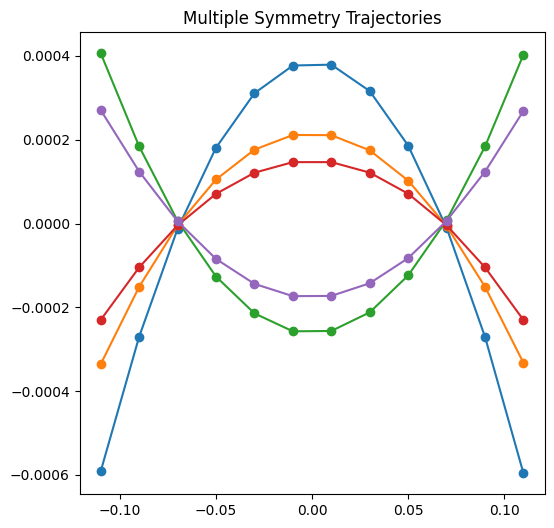

In [14]:
plt.figure(figsize=(6,6))

for i in range(5):

    z = latent_vectors[i*12].unsqueeze(0).to(device)

    traj = []

    for _ in range(12):

        traj.append(z.cpu().numpy()[0])

        with torch.no_grad():

            z = z + epsilon*generator(z)

    traj = np.array(traj)

    traj_pca = PCA(n_components=2).fit_transform(traj)

    plt.plot(traj_pca[:,0],traj_pca[:,1],marker='o')

plt.title("Multiple Symmetry Trajectories")

plt.show()

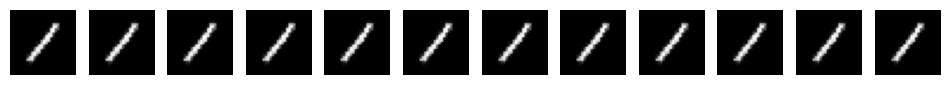

In [15]:
sequence = []

z = latent_vectors[0].unsqueeze(0).to(device)

for i in range(12):

    with torch.no_grad():

        recon = vae.decoder(z)

    sequence.append(recon.cpu())

    z = z + epsilon*generator(z)

plt.figure(figsize=(12,2))

for i in range(12):

    plt.subplot(1,12,i+1)

    plt.imshow(sequence[i][0,0],cmap="gray")

    plt.axis("off")

plt.show()

In [16]:
z = latent_vectors[0].unsqueeze(0).to(device)

z_start = z.clone()

for _ in range(12):

    z = z + epsilon*generator(z)

cycle_error = torch.norm(z - z_start)

print("Cycle consistency error:",cycle_error.item())

Cycle consistency error: 0.23998498916625977


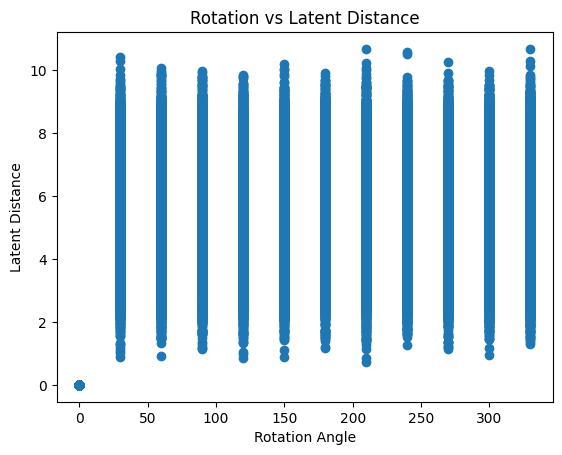

In [17]:
# Rotation vs latent displacement

distances = []

for i in range(0,len(latent_vectors),12):

    group = latent_vectors[i:i+12]

    base = group[0]

    for j in range(12):

        dist = torch.norm(group[j]-base).item()

        angle = j*30

        distances.append((angle,dist))

angles_list = [x[0] for x in distances]
dists = [x[1] for x in distances]

plt.scatter(angles_list,dists)

plt.xlabel("Rotation Angle")
plt.ylabel("Latent Distance")

plt.title("Rotation vs Latent Distance")

plt.show()

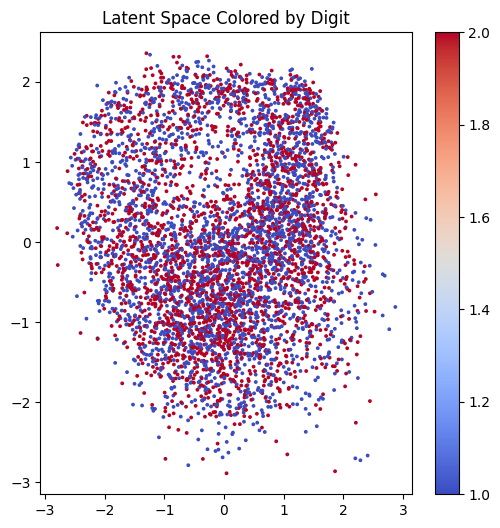

In [18]:
sample_z = latent_vectors[:5000].numpy()

sample_labels = labels.repeat_interleave(12)[:5000]

pca = PCA(n_components=2)

z_2d = pca.fit_transform(sample_z)

plt.figure(figsize=(6,6))

plt.scatter(
    z_2d[:,0],
    z_2d[:,1],
    c=sample_labels,
    cmap="coolwarm",
    s=3
)

plt.colorbar()

plt.title("Latent Space Colored by Digit")

plt.show()

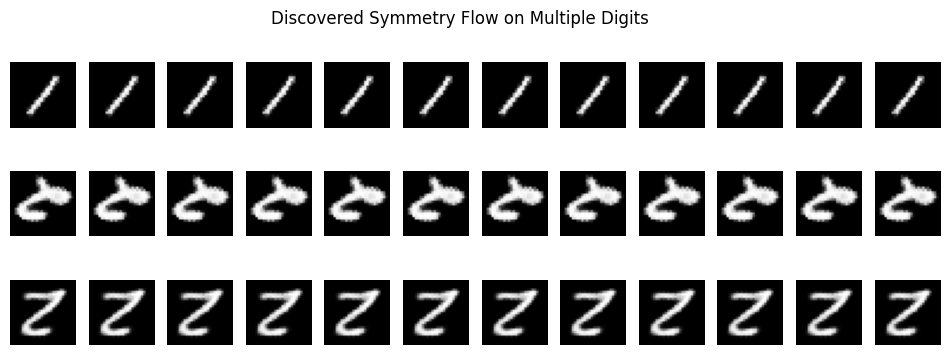

In [19]:
plt.figure(figsize=(12,4))

for i in range(3):

    z = latent_vectors[i*12].unsqueeze(0).to(device)

    sequence = []

    for _ in range(12):

        with torch.no_grad():

            recon = vae.decoder(z)

        sequence.append(recon.cpu())

        z = z + epsilon*generator(z)

    for j in range(12):

        plt.subplot(3,12,i*12+j+1)

        plt.imshow(sequence[j][0,0],cmap="gray")

        plt.axis("off")

plt.suptitle("Discovered Symmetry Flow on Multiple Digits")

plt.show()

In [20]:
class MultiSymmetryGenerator(nn.Module):

    def __init__(self, latent_dim, k=3):

        super().__init__()

        self.latent_dim = latent_dim
        self.k = k

        self.net = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,k*latent_dim)
        )

    def forward(self,z):

        g = self.net(z)

        g = g.view(-1,self.k,self.latent_dim)

        g = F.normalize(g,dim=2)

        return g

In [21]:
num_generators = 3

multi_generator = MultiSymmetryGenerator(
    latent_dim,
    num_generators
).to(device)

optimizer = torch.optim.Adam(
    multi_generator.parameters(),
    lr=3e-4
)

epsilon = 0.02

In [22]:
epochs = 30

for epoch in range(epochs):

    total_loss = 0

    for z_batch,_ in loader:

        z_batch = z_batch.to(device)

        g = multi_generator(z_batch)

        invariance_loss = 0

        for i in range(num_generators):

            z_new = z_batch + epsilon*g[:,i,:]

            logits_old = classifier(z_batch)
            logits_new = classifier(z_new)

            invariance_loss += F.mse_loss(
                logits_old,
                logits_new
            )

        invariance_loss /= num_generators

        norm_loss = ((torch.norm(g,dim=2)-1)**2).mean()

        ortho_loss = 0

        for i in range(num_generators):
            for j in range(i+1,num_generators):

                dot = torch.sum(
                    g[:,i,:]*g[:,j,:],
                    dim=1
                )

                ortho_loss += torch.mean(dot**2)

        loss = invariance_loss + 0.1*norm_loss + 0.1*ortho_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        "Epoch",
        epoch+1,
        "Loss",
        total_loss/len(loader)
    )

Epoch 1 Loss 0.00015063618369541722
Epoch 2 Loss 6.418936483908894e-06
Epoch 3 Loss 3.3245045664742846e-06
Epoch 4 Loss 2.423772901851859e-06
Epoch 5 Loss 2.008376324224231e-06
Epoch 6 Loss 1.7691917718512809e-06
Epoch 7 Loss 1.612477309748974e-06
Epoch 8 Loss 1.490355820070613e-06
Epoch 9 Loss 1.389609468675043e-06
Epoch 10 Loss 1.30386269426934e-06
Epoch 11 Loss 1.231357629099088e-06
Epoch 12 Loss 1.1658692651950858e-06
Epoch 13 Loss 1.1049541896282246e-06
Epoch 14 Loss 1.0496491492956358e-06
Epoch 15 Loss 1.006869054732617e-06
Epoch 16 Loss 9.617964276046205e-07
Epoch 17 Loss 9.217210249333818e-07
Epoch 18 Loss 8.78277551935405e-07
Epoch 19 Loss 8.445331722124143e-07
Epoch 20 Loss 8.087544058228394e-07
Epoch 21 Loss 7.78637515770163e-07
Epoch 22 Loss 7.433012598503166e-07
Epoch 23 Loss 7.164682667521538e-07
Epoch 24 Loss 6.902812238585766e-07
Epoch 25 Loss 6.684953476205797e-07
Epoch 26 Loss 6.443312456469248e-07
Epoch 27 Loss 6.294686084588373e-07
Epoch 28 Loss 6.13180658642201e-07

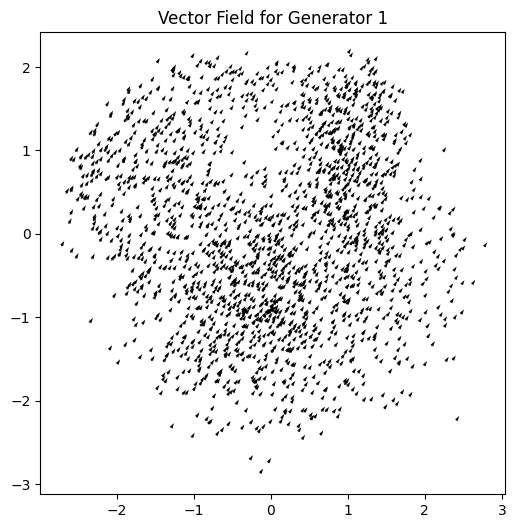

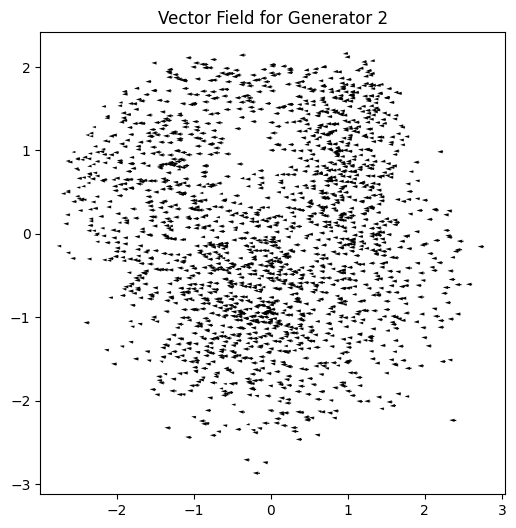

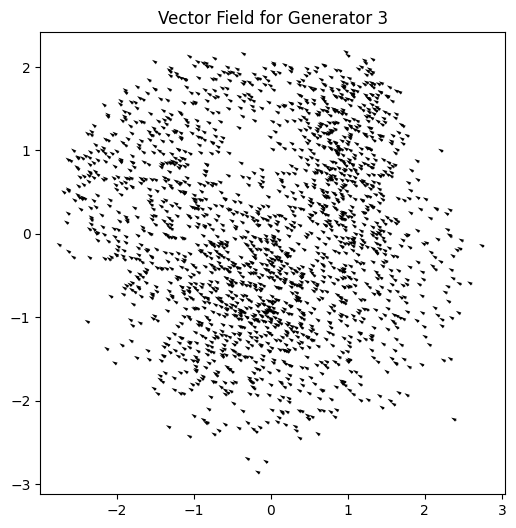

In [23]:
sample_z = latent_vectors[:2000].numpy()

pca = PCA(n_components=2)

z_2d = pca.fit_transform(sample_z)

with torch.no_grad():

    g = multi_generator(
        torch.tensor(sample_z).float().to(device)
    ).cpu().numpy()

for gen_id in range(num_generators):

    g_i = g[:,gen_id,:]

    z_next = sample_z + epsilon*g_i

    z_next_2d = pca.transform(z_next)

    dx = z_next_2d[:,0]-z_2d[:,0]
    dy = z_next_2d[:,1]-z_2d[:,1]

    plt.figure(figsize=(6,6))

    plt.quiver(
        z_2d[:,0],
        z_2d[:,1],
        dx,
        dy
    )

    plt.title(
        f"Vector Field for Generator {gen_id+1}"
    )

    plt.show()

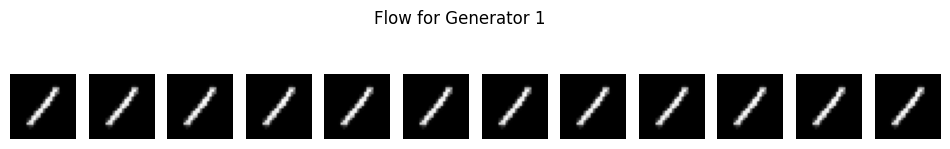

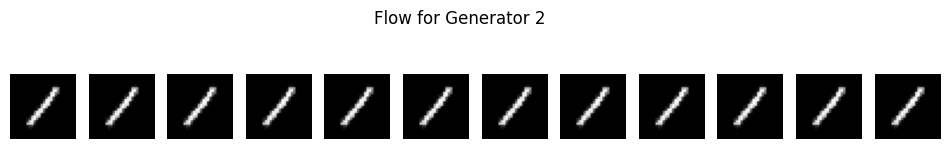

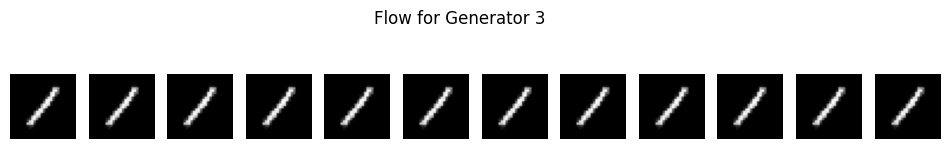

In [24]:
for gen_id in range(num_generators):

    z = latent_vectors[0].unsqueeze(0).to(device)

    sequence = []

    for _ in range(12):

        with torch.no_grad():

            recon = vae.decoder(z)

        sequence.append(recon.cpu())

        g = multi_generator(z)

        z = z + epsilon*g[:,gen_id,:]

    plt.figure(figsize=(12,2))

    for i in range(12):

        plt.subplot(1,12,i+1)

        plt.imshow(
            sequence[i][0,0],
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Flow for Generator {gen_id+1}"
    )

    plt.show()

In [25]:
with torch.no_grad():

    z = latent_vectors[:1000].to(device)

    g = multi_generator(z)

    for i in range(num_generators):

        z_new = z + epsilon*g[:,i,:]

        logits_old = classifier(z)
        logits_new = classifier(z_new)

        diff = torch.mean(
            (logits_old-logits_new)**2
        )

        print(
            f"Generator {i+1} invariance error:",
            diff.item()
        )

Generator 1 invariance error: 4.6122454477881547e-07
Generator 2 invariance error: 4.87007071114931e-07
Generator 3 invariance error: 4.782074825016025e-07
